In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.formula.api as smf
import statsmodels.tools.eval_measures as metrics

In [8]:
file_path = 'https://drive.google.com/uc?id=16g-VsVZVTVy1QZljY1bZEWvFcsT3CS2v'
# df = pd.read_csv(file_path, sep = ',')
df = pd.read_csv(file_path, sep=',', on_bad_lines='skip')

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [10]:
# Lectura de datos
df = pd.read_csv('precios-propiedades (2).csv')

In [11]:
# visualización inicial de una muestra del set de datos
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
97,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2.0,276.0,18.0,396.90,4.21,38.7
255,0.03548,80.0,3.64,0.0,0.392,5.876,19.1,9.2203,1.0,315.0,16.4,395.18,9.25,20.9
227,0.41238,0.0,6.20,0.0,0.504,7.163,79.9,3.2157,8.0,307.0,17.4,372.08,6.36,31.6
491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07,13.6
470,4.34879,0.0,18.10,0.0,0.580,6.167,84.0,3.0334,24.0,666.0,20.2,396.90,16.29,19.9


In [12]:
# dimensión del set de datos
df.shape

(506, 14)

# Descripción del Data Set
El dataset contiene 14 columnas

• **CRIM**: Tasa de criminalidad per cápita del sector

• **ZN**: Proporción de suelo residencial para lotes sobre 25,000 sq ft

• **INDUS**: Proporción de negocios no-retail por sector

• **CHAS**: 1 si el tramo limita con el Río Biobío, caso contrario, 0

• **NOX**: Concentración óxido nítrico (part per 10 million)

• **RM**: Promedio número de dormitorios por vivienda

• **AGE**: Proporción de viviendas ocupadas por sus propietarios construidas previo a 1940

• **DIS**: Distancias ponderadas a cinco centros de empleo de Boston

• **RAD**: Índice de accesibilidad a carreteras radiales

• **TAX**: Tasa de impuesto a la propiedad de valor total por $ 10,000

• **PTRATIO**: Proporción alumno-profesor por ciudad

• **B**: 1000 (Bk - 0,63) ², donde Bk es la proporción de (personas de otras etnias) por sector

• **LSTAT**: Porcentaje de menor estatus de la población

• **MEDV**: Valor de las viviendas en 1000 US

# Análisis Exploratorio

In [13]:
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
424,8.79212,0.0,18.10,0.0,0.584,5.565,70.6,2.0635,24.0,666.0,20.2,3.65,17.16,11.7
430,8.49213,0.0,18.10,0.0,0.584,6.348,86.1,2.0527,24.0,666.0,20.2,83.45,17.64,14.5
213,0.14052,0.0,10.59,0.0,0.489,6.375,32.3,3.9454,4.0,277.0,18.6,385.81,9.38,28.1
296,0.05372,0.0,13.92,0.0,0.437,6.549,51.0,5.9604,4.0,289.0,16.0,392.85,7.39,27.1
343,0.02543,55.0,3.78,0.0,0.484,6.696,56.4,5.7321,5.0,370.0,17.6,396.90,7.18,23.9


* El dataset tiene 506 filas y 14 columnas.

* Cada fila tiene valores para 14 variables como CRIM, ZN, INDUS, etc.

* La columna objetivo es MEDV, que representa el valor mediano de las casas (en miles de dólares).

* Las filas seleccionadas muestran los valores de estas 14 variables para ciertas observaciones de casas en el dataset.


In [15]:
# No hay valore nulos en el set de datos
# Todas las variables son de tipo númericas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


* **Non-Null Count: 506 non-null:** Muestra que no hay valores nulos en ninguna de las columnas, lo que es positivo porque significa que todos los datos están completos.

* **Dtype: float64:** Indica que todas las columnas son de tipo número de punto flotante (decimales), lo que sugiere que estás trabajando con datos continuos.

* El conjunto de datos está limpio (sin valores nulos) y todas las variables son numéricas

In [16]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


* Las siguientes líneas presentan estadísticas para cada columna numérica.

* **count:** El número de entradas en cada columna. Aquí, todos los valores son 506, lo que confirma que no hay datos faltantes en ninguna columna.

* **mean (promedio):** Representa el valor promedio de cada columna.

* **std (desviación estándar):** Mide la dispersión de los datos respecto a la media.

* **min (mínimo):** El valor más bajo en cada columna. 

* **25% (primer cuartil):** Este es el valor por debajo del cual se encuentra el 25% de los datos.

* **50% (mediana):** El valor medio que divide los datos en dos mitades.

* **75% (tercer cuartil):** Este es el valor por debajo del cual se encuentra el 75% de los datos.

* **max (máximo):** El valor más alto en cada columna.

<Axes: >

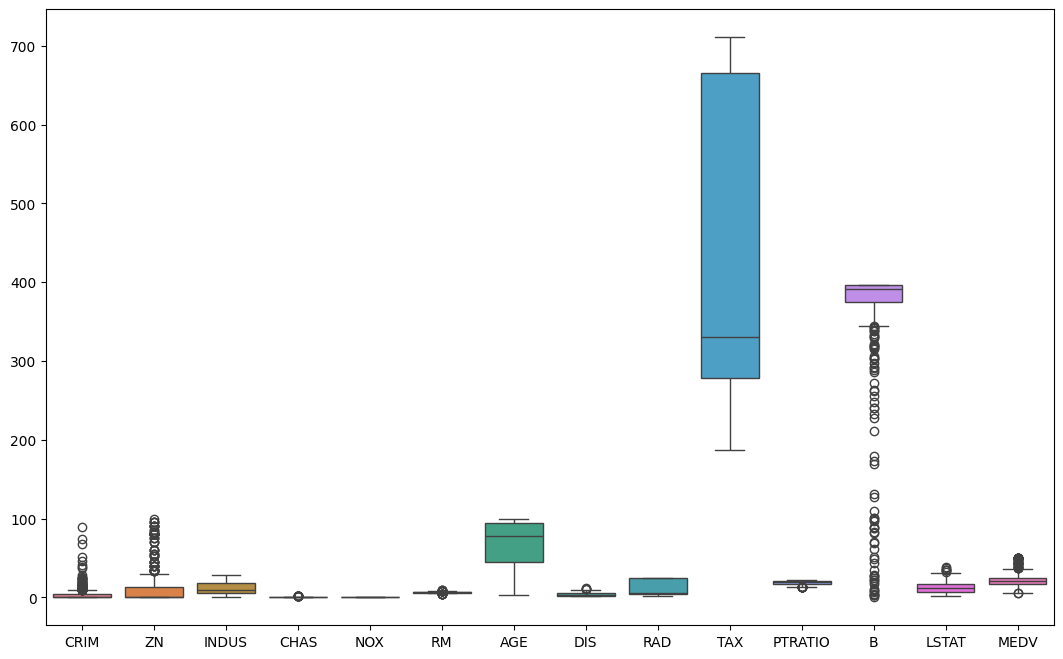

In [18]:
plt.figure(figsize=(13,8))
sns.boxplot(df)

#### **CRIM (Tasa de criminalidad per cápita):**

* **Distribución**: Hay una gran cantidad de valores atípicos, lo que indica que hay algunos lugares con tasas de criminalidad excepcionalmente altas.
* **Mediana**: Relativamente baja, lo que sugiere que la mayoría de los barrios tienen tasas de criminalidad más bajas.



#### **ZN (Porcentaje de suelo residencial de más de 25,000 pies cuadrados):**

* **Distribución:** La mayoría de los valores están en 0, lo que sugiere que muchos de los barrios no tienen zonas residenciales extensas.

* **Outliers:** Pocos outliers hacia arriba, lo que indica que hay algunas áreas con gran proporción de zonas residenciales.

#### **INDUS (Proporción de acres de negocios no minoristas):**

* **Distribución:** Similar a ZN, con pocos valores significativos, indicando una baja presencia de zonas industriales.

#### **CHAS (Variable dummy que toma 1 si está al lado del río Charles):**

* **Distribución:** Solo dos valores (0 y 1), lo que indica que esta es una variable categórica que representa la proximidad al río.

#### **NOX (Concentración de óxido nítrico):**

* **Distribución:** Los valores son bastante bajos, pero hay algunos outliers, lo que sugiere que hay lugares con alta contaminación.

#### **RM (Número promedio de habitaciones por vivienda):**

* **Distribución:** La mediana es razonablemente alta, con pocos valores atípicos en el extremo superior, lo que indica que la mayoría de las casas tienen un número moderado de habitaciones.

#### **AGE (Proporción de unidades ocupadas por propietarios):**

* **Distribución:** La mayoría de los valores están en un rango medio, pero hay outliers, lo que indica que algunas áreas tienen muchas casas viejas.

#### **DIS (Distancias ponderadas a cinco centros de empleo en Boston):**

* **Distribución:** La mayoría de los valores son bajos, lo que sugiere que muchas áreas están relativamente cerca de los centros de empleo.

#### **RAD (Índice de accesibilidad a carreteras radiales):**

* **Distribución:** Principalmente en valores bajos, lo que indica que muchas áreas tienen un acceso limitado a las carreteras.

#### **TAX (Tasa de impuestos sobre la propiedad):**

* **Distribución:** La mediana es alta, con varios outliers, indicando que algunas áreas tienen tasas impositivas muy elevadas.

#### **PTRATIO (Proporción de estudiantes por maestro):**

* **Distribución:** La mayoría de los barrios tienen una proporción de estudiantes por maestro bastante buena, aunque hay algunos outliers indicando áreas con alta carga de estudiantes.

#### **B (Índice de población negra):**

* **Distribución:** La mayoría de los valores son bajos, lo que indica que la población negra en estos barrios es en general baja.

#### **LSTAT (Porcentaje de población con bajo estatus socioeconómico):**

* **Distribución:** Tiene varios valores atípicos, indicando que algunas áreas tienen un porcentaje muy alto de población de bajo estatus.

#### **MEDV (Valor medio de las viviendas en miles de dólares):**

* **Distribución:** La mediana es relativamente alta, pero hay outliers hacia el extremo superior, indicando la presencia de casas muy caras en algunas áreas.

In [37]:
# Funcion para aplicar la suma de valores unicos a cada columna
def get_value_counts(df):
    cols = df.columns
    unique_dict = {}
    for col in cols:
        unique_dict[col] = df[col].astype(str).value_counts()

    return unique_dict

df['CHAS'] = df['CHAS'].astype(float)
df['RAD'] = df['RAD'].astype(float)

In [38]:
get_value_counts(df)

{'CRIM': CRIM
 0.01501    2
 14.3337    2
 0.03466    1
 0.03113    1
 0.03049    1
           ..
 1.51902    1
 1.83377    1
 1.46336    1
 1.27346    1
 0.04741    1
 Name: count, Length: 504, dtype: int64,
 'ZN': ZN
 0.0      372
 20.0      21
 80.0      15
 22.0      10
 12.5      10
 25.0      10
 40.0       7
 45.0       6
 30.0       6
 90.0       5
 95.0       4
 60.0       4
 21.0       4
 33.0       4
 55.0       3
 70.0       3
 34.0       3
 52.5       3
 35.0       3
 28.0       3
 75.0       3
 82.5       2
 85.0       2
 17.5       1
 100.0      1
 18.0       1
 Name: count, dtype: int64,
 'INDUS': INDUS
 18.1     132
 19.58     30
 8.14      22
 6.2       18
 21.89     15
         ... 
 1.21       1
 1.38       1
 3.75       1
 0.46       1
 2.31       1
 Name: count, Length: 76, dtype: int64,
 'CHAS': CHAS
 0.0    471
 1.0     35
 Name: count, dtype: int64,
 'NOX': NOX
 0.538    23
 0.713    18
 0.437    17
 0.871    16
 0.624    15
          ..
 0.394     1
 0.518    

In [39]:
unique_counts = get_value_counts(df)
#counts_df = pd.DataFrame({col: val for col, val in unique_counts.items()})
counts_df = pd.DataFrame(list(unique_counts.items()), columns=['Variable', 'Unique Count'])
counts_df = counts_df.fillna(0)
counts_df = counts_df.sort_values(by='Unique Count', ascending=False)
print(counts_df)



ValueError: Can only compare identically-labeled Series objects

* Función get_value_counts(df) está diseñada para contar los valores únicos en cada columna del DataFrame df y devolver un diccionario con estos conteos.

* Para la columna CRIM, hay un total de 504 valores únicos con varios conteos.
* Para la columna ZN, hay 372 entradas con un valor de 0.0, lo que sugiere que la mayoría de los registros no tienen áreas residenciales grandes.

## Análisis univariado variable CHAS y RAD

Al observar la estructura de los datos de CHAS y RAD, estas asumen datos numéricas, pero en escencia son valores categóricos. CHAS asume valores binarios de 0 y 1, y RAD índices numéricos del 1 al 8, y el 24. Por lo tanto, procederemos a ajustar la estructura de CHAS y RAD a tipo str.

In [20]:
df['CHAS'] = df['CHAS'].apply(str)
df['RAD'] = df['RAD'].apply(str)

In [21]:
# Ahora CHAS y RAD son variables categóricas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    object 
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    object 
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), object(2)
memory usage: 55.5+ KB


In [192]:
# Valores unicos en dimensión CHAS
df['CHAS'].unique()

array(['0.0', '1.0'], dtype=object)

In [193]:
# Frecuencia de valores en la dimensión CHAS
df['CHAS'].value_counts()

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

(array([471.,  35.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

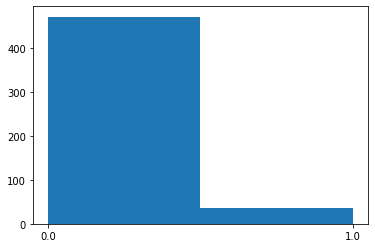

In [194]:
plt.hist(df['CHAS'], bins = 2)

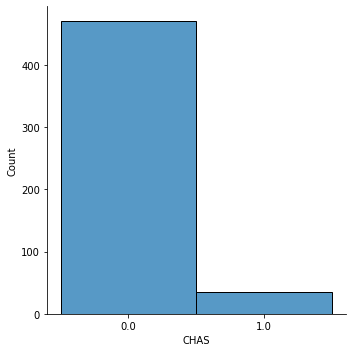

In [195]:
sns.displot(data=df, x='CHAS', bins=2, kind = 'hist')

Utilizamos la moda como medida de tendencia central en CHAS y comprobamos que el registro con mayor frecuencia es el 0, por lo tanto la mayoría de las propiedades no limitan con el río Bío Bío

Veamos la variable RAD:

In [196]:
df.RAD.describe()

count      506
unique       9
top       24.0
freq       132
Name: RAD, dtype: object

In [197]:
df.RAD.value_counts()

RAD
24.0    132
5.0     115
4.0     110
3.0      38
6.0      26
8.0      24
2.0      24
1.0      20
7.0      17
Name: count, dtype: int64

<Axes: xlabel='RAD', ylabel='count'>

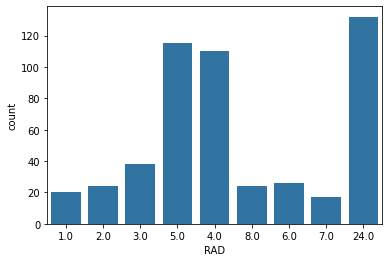

In [198]:
sns.countplot(data=df, x='RAD')

Podemos observar que si bien el indice '24' no sigue la secuencia, este registra la mayor frecuencia. Por tanto, gran parte de las propiedades tiene un indice alto de acceso a las carreteras

## Análisis univariado de LSTAT

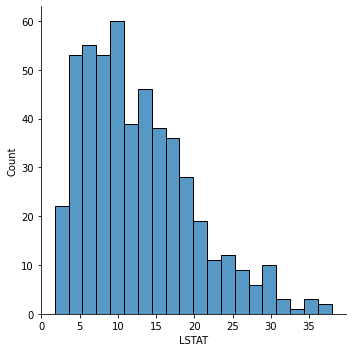

In [199]:
sns.displot(data=df, x='LSTAT', bins=20)

In [200]:
df.LSTAT.describe()

count    506.000000
mean      12.653063
std        7.141062
min        1.730000
25%        6.950000
50%       11.360000
75%       16.955000
max       37.970000
Name: LSTAT, dtype: float64

<Axes: xlabel='LSTAT'>

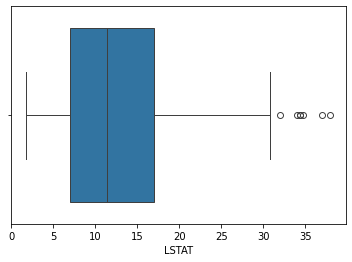

In [201]:
sns.boxplot(data=df, x='LSTAT')

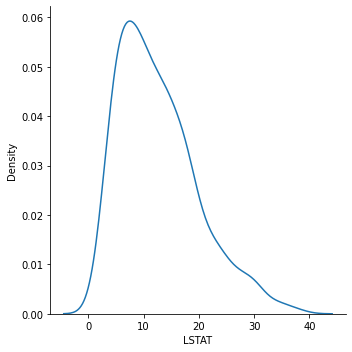

In [202]:
sns.displot(data=df, x='LSTAT', kind='kde')

En promedio, las casas cuentan con un indice de 12.65. Podemos apreciar que al alegir un vivienda, es más probable que ésta se encuentre en un indice de poblacion de estatuts medio; entre 6.95 y 16.95, con una variabilidad de 7.14 unidades.

## Análisis univariado de MEDV (valor de la vivienda)

Veremos la relación de estas categoría con el precio de las propiedades

In [203]:
df.MEDV.describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64

<Axes: xlabel='MEDV'>

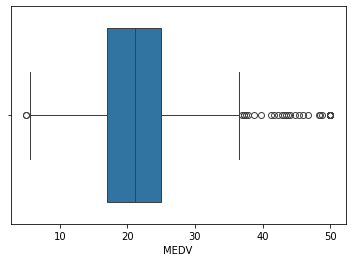

In [204]:
sns.boxplot(data=df, x='MEDV')

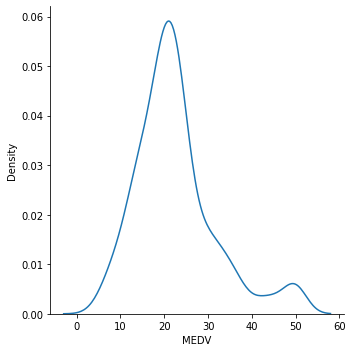

In [205]:
sns.displot(data=df, x='MEDV', kind='kde')

In [206]:
# Límite superior
q1 = df['MEDV'].quantile(.25)
q2 = df['MEDV'].quantile(.5)
q3 = df['MEDV'].quantile(.75)
RIQ = q3-q1
print("Rango Inter cuartil:", RIQ)
print("q1:", q1)
print("q2:", q2)
print("q3:", q3)
ls_MEDV = q3 + 1.5*RIQ
print("limite superior:", ls_MEDV)

Rango Inter cuartil: 7.975000000000001
q1: 17.025
q2: 21.2
q3: 25.0
limite superior: 36.962500000000006


Podemos ver que es más probable encontrar precios entre 10 y 30. Sin embargo, hay valores atípico que exceden del rango normal de precios (limite superior = 36.96)

Veamos como se relacionan nuestra categoria CHAS con los precios

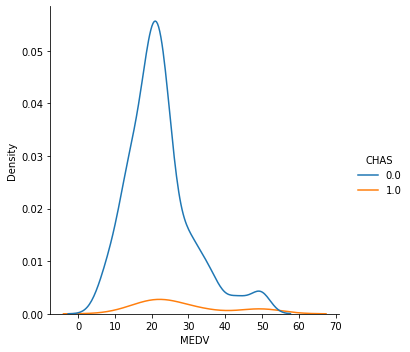

In [207]:
sns.displot(data=df, x='MEDV', kind='kde', hue='CHAS')

<Axes: xlabel='CHAS', ylabel='MEDV'>

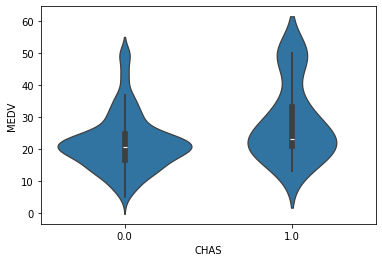

In [208]:
sns.violinplot(data=df, x='CHAS', y='MEDV')

In [209]:
df.groupby('CHAS')['MEDV'].describe()

,count,mean,std,min,25%,50%,75%,max
CHAS,,,,,,,,
0.0,471.0,22.093843,8.831362,5.0,16.6,20.9,24.80,50.0
1.0,35.0,28.440000,11.816643,13.4,21.1,23.3,33.15,50.0


Notamos que el indice 1 (la propiedad limita con el rio) tiende a tener precios medios más elevados y más dispersos. Las viviendas que no limitan con el rio tienden a tener precios más uniformes. En ambos casos, el precio máximo alcanza los 50 mil dólares. Por otro lado, la probabilidad de encontrar propiedades que limiten con el rio, es mucho menor.

Veamos sel caso de RAD con los precios

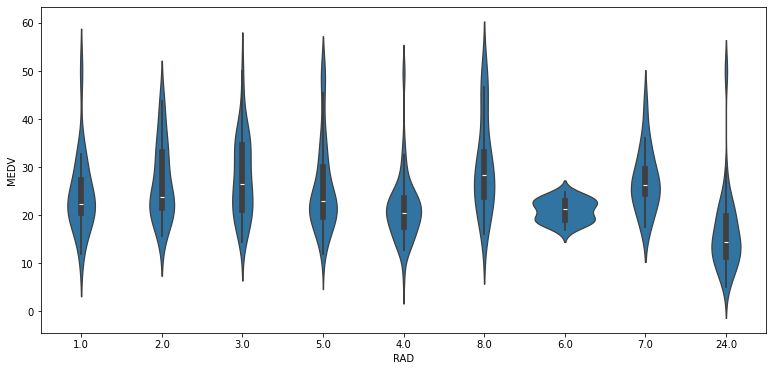

In [210]:
plt.figure(figsize=(13, 6))
sns.violinplot(data=df, x='RAD', y='MEDV')
plt.show()

Podemos ver que el precio de los indices del 1 al 8 son dispersos. Luego,  el indice 6 presenta mayor uniformidad, sin presencia de precios extremos. De forma similiar al indice 6, se comporta el indice 7, con mayor rango de precios, pero sin mucha dispersión como sus antecesores. Por último el indice 8 presenta concentración de precios más bajos y precios atípicos.


## Análisis correlativo

Veamos como se relacionan las demás variables con los precios a través de la correlación de Pearson

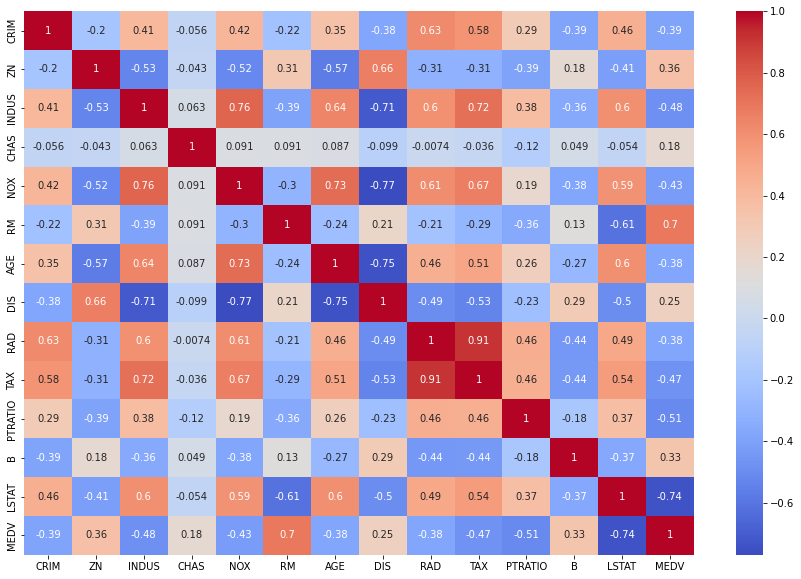

In [211]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.show()

Podemos ver que los precios tienen mayor relación con la variable RM (0.7) y LSTAT(-0.74). A medida que aumenta el índice de menor estatus, los precios bajan, en cambio, estos suben cuando el número de dormitorios es mayor.

# Modelo Regresivo
A continuación analizaremos la relación entre el precio, el número de habitaciónes, y porcentaje de menor status de la población.
Contestaremos las siguientes preguntas:

- ¿Existe relación entre el precio el número de habitaciones?
- ¿Existe relación entre el precio y el indice de vulnerabilidad?
- De existir relación, ¿tiene comportamiento lineal?
- ¿Podemos realizar un modelo predictivo para el precio con las demas variables?
- ¿Cúan buena podría ser esa predicción?

## Hipótesis  de trabajo

El precio de una propiedad depende de forma lineal del número de habitaciones y del índice de vulnerabilidad del sector


<Axes: xlabel='LSTAT', ylabel='MEDV'>

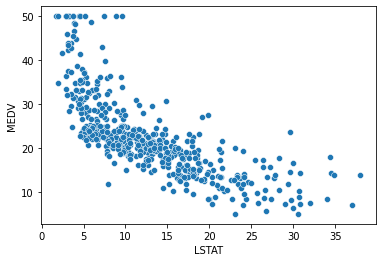

In [212]:
# La representación visual entre el indice y el precio, nos muestra una relación
# lineal decreciente
sns.scatterplot(data=df, x='LSTAT', y='MEDV')

<Axes: xlabel='RM', ylabel='MEDV'>

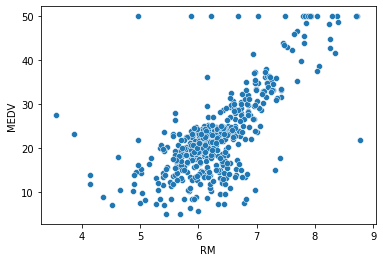

In [213]:
# La representación visual entre el numero de habitaciones y el precio, nos muestra una relación
# lineal creciente
sns.scatterplot(data=df, x='RM', y='MEDV')

## Selección de predictores

In [214]:
df[['MEDV', 'LSTAT', 'RM']].corr()

,MEDV,LSTAT,RM
MEDV,1.000000,-0.737663,0.695360
LSTAT,-0.737663,1.000000,-0.613808
RM,0.695360,-0.613808,1.000000


### - Si bien existe una correlación entre LSTAT y RM, es de fuerza media, por lo tanto descartamos multicolinealidad

### - Ajustaremos primeramente un modelo lineal con la  LSTAT, ya que tiene mayor correlación (-0.74)


## Ajuste deL modelo lineal

In [215]:
lm = smf.ols(data=df, formula='MEDV ~ LSTAT').fit()

In [216]:
lm.params

Intercept    34.553841
LSTAT        -0.950049
dtype: float64

In [217]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           5.08e-88
Time:                        03:29:01   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.000      33.448      35.659
LSTAT         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Los parámetros nos indican que:
- El aumento de 1 unidad en el índice LSTAT está asociado a la disminución de 950 dólares
<!-- - Por cada dormitorio adicional el precio de la propiedad aumenta en 5000 dólares -->

- los P value de la variable predictora se encuentran por debajo del nivel de significancia (0.05), por lo tanto se mantiene en el modelo

- Nuestro modelo es capaz de explicar el 54,3% de la variabilidad.

In [218]:
lm2 = smf.ols(data=df, formula='MEDV ~ LSTAT + RM').fit()

In [219]:
lm2.params

Intercept   -1.358273
LSTAT       -0.642358
RM           5.094788
dtype: float64

In [220]:
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     444.3
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          7.01e-112
Time:                        03:29:01   Log-Likelihood:                -1582.8
No. Observations:                 506   AIC:                             3172.
Df Residuals:                     503   BIC:                             3184.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3583      3.173     -0.428      0.669      -7.592       4.875
LSTAT         -0.6424      0.044    -14.689      0.000      -0.728      -0.556
RM             5.0948      0.444     11.463      0.000       4.222       5.968
==============================================================================
Omnibus:                      145.712   Durbin-Watson:                   0.834
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              457.690
Skew:                           1.343   Prob(JB):                    4.11e-100
Kurtosis:                       6.807   Cond. No.                         202.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- Podemos observar que ambos p values se encuentra por debajo de 0.05 y que a su vez el R2 ajustado aumenta 0.637 respecto del modelo anterior, siendo un modelo más robusto.
- El aumento de 1 unidad en el índice LSTAT está asociado a la disminución de 642 dólares
- Por cada dormitorio adicional el precio de la propiedad aumenta en 5100 dólares

## Métricas de evaluación del modelo

In [221]:
y_true = df['MEDV']
y_pred = lm2.predict(df[['LSTAT','RM' ]])
print( 'MAE: {}'.format(metrics.meanabs(y_true,y_pred)) )
print( 'MSE: {}'.format(metrics.mse(y_true,y_pred)) )
print( 'RMSE: {}'.format(metrics.rmse(y_true,y_pred)) )
print( 'R2: {}'.format(lm2.rsquared))
print( 'R2-Adj: {}'.format(lm2.rsquared_adj))

MAE: 3.952580067119268
MSE: 30.51246877729947
RMSE: 5.523809263298243
R2: 0.6385616062603404
R2-Adj: 0.6371244754701231


Con lo anterior, podemos realizar un predicción del precio de una propiedad tomando LSTAT y RM, y esperar un error absoluto medio de 3953 dólares.

Text(0, 0.5, 'Predicción Y')

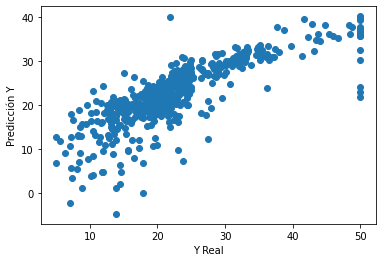

In [222]:
plt.scatter(y_true,y_pred)
plt.xlabel('Y Real')
plt.ylabel('Predicción Y')

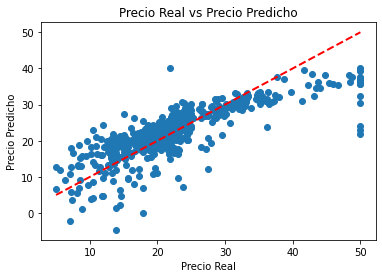

In [223]:
plt.scatter(y_true, y_pred)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Precio Real vs Precio Predicho')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.show()

## Análisis de Residuales

<Axes: ylabel='Density'>

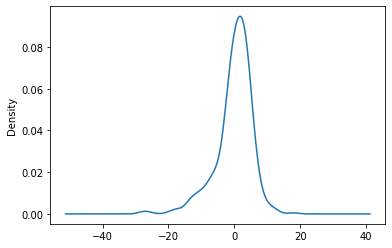

In [224]:
# Con este gráfico comprobamos que el error se distribuye de forma normal
(y_pred - y_true).plot(kind='kde')

C:\Users\Equipo\AppData\Local\Temp\ipykernel_21480\2386858460.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred - y_true)


<Axes: ylabel='Density'>

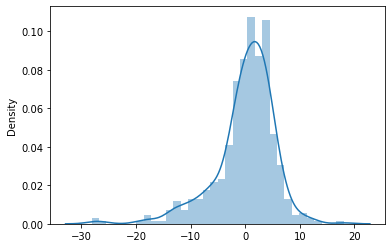

In [225]:
sns.histplot(y_pred - y_true)

In [ ]:
Se observa que los residuos se distribuyen de forma normal. Y su centro se encuentra cercano al valor 0, por lo que se deduce que el modelo lineal representa la variable que se quiere estudiar.